> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib pandas


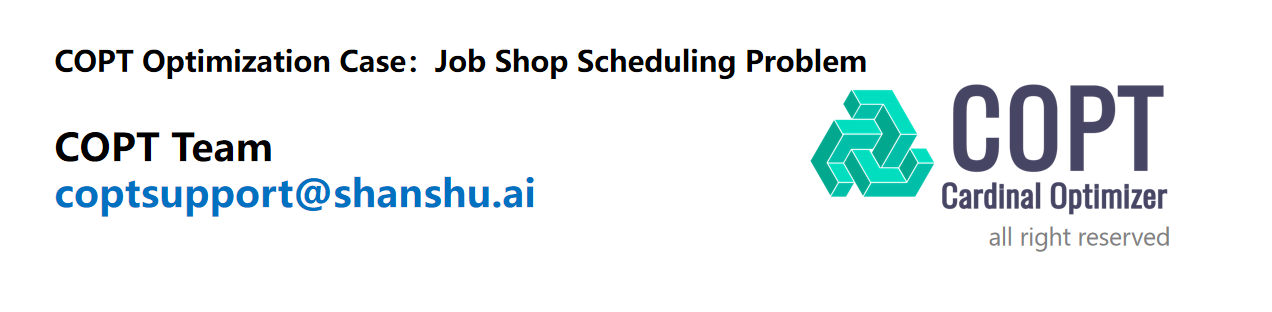

# Job Shop Scheduling Problem: Code Implementation
## Steps to Model and Solve Job Shop Scheduling Problem using COPT
1. **Import COPT-Python interface library** `coptpy`

2. **Add model data**

3. **Create COPT solving environment and model**

4. **Build the model and add the three elements of the model in sequence**
    - **Decision Variables**:
      - $C_{j,k} \in \mathbb{R}^+$：Continuous variable, representing the completion time node of job $j$ at stage $k$.
      - $x_{i,j,k} \in \{0,1\}$：0-1 variable, representing the mutually exclusive order of jobs on a machine. It takes 1 if the processing of job $i$ at stage $k$ is scheduled after job $j$, and 0 otherwise.
      - $C_{max} \in \mathbb{R}^+$：Continuous variable, representing the maximum completion time of the entire batch of jobs.
    - **Objective Function**:
        - Minimize the makespan of all jobs:$ \min  C_{max} $
    - **Constraints**:
        - **Logical rationality constraint for the initial stage**
        - **Stage processing sequence constraint**
        - **Mutually exclusive sequencing constraint (Big-M method)**
        - **Maximum completion time constraint**

5. **Solve**

6. View and analyze solution **results**

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT
from itertools import combinations

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import random

## Add Mmodel data

In [6]:
# Data
jobs = [0, 1, 2]
stages = [0, 1, 2]
Proc_time = [
    [3, 2, 4],
    [2, 5, 1],
    [4, 3, 2],
]
M =1e4  # A sufficiently large constant

## Create the COPT environment and model

In [8]:
# Initialize the model
env = cp.Envr()
model = env.createModel("multi_stage_schedule")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model
### Add Decision Variables

- $C_{j,k} \in \mathbb{R}^+$：Continuous variable, representing the completion time node of job $j$ at stage $k$.
- $x_{i,j,k} \in \{0,1\}$：0-1 variable, representing the mutually exclusive order of jobs on a machine. It takes 1 if the processing of job $i$ at stage $k$ is scheduled after job $j$, and 0 otherwise.
- $C_{max} \in \mathbb{R}^+$：Continuous variable, representing the maximum completion time of the entire batch of jobs.

In [10]:
# Define variables: Completion time
C = {}
for j in jobs:
    for k in stages:
        C[j, k] = model.addVar(name=f"C_{j}_{k}")

In [11]:
# Define variables: Processing order
x = {}
for k in stages:
    for i, j in combinations(jobs, 2):
        x[i, j, k] = model.addVar(vtype=COPT.BINARY, name=f"x_{i}_{j}_{k}")
        x[j, i, k] = model.addVar(vtype=COPT.BINARY, name=f"x_{j}_{i}_{k}")

In [12]:
# Makespan
C_max = model.addVar(name="C_max")

### Set Objective Function

Minimize the makespan of all jobs:
$$ \min  C_{max} $$

In [14]:
model.setObjective(C_max, sense=COPT.MINIMIZE)

### Add Constraints
1. **Logical rationality constraint for the initial stage**: Requires that the completion time of all jobs in the initial stage must be greater than or equal to their processing duration in that stage, acting as the natural physical starting point of the timeline.
$$ C_{j,0} \ge Proc\_time_{j,0}, \quad \forall j \in J $$

In [16]:
# Logical rationality constraint: the completion time lower bound for the initial stage is its processing time
for j in jobs:
    model.addConstr(C[j, 0] >= Proc_time[j][0])  

2. **Stage processing sequence constraint**: Each job must be processed in the sequential order of the stages; the next stage can only start after the previous one is completed. That is, the completion time of job $j$ in the current stage $k$ must be greater than or equal to the sum of its completion time in the previous stage $k-1$ and the current stage's processing duration, ensuring no time overlap or logical inversion between operations.
$$ C_{j,k} \ge C_{j,k-1} + Proc\_time_{j,k}, \quad \forall j \in J, k = 1, 2 $$

In [18]:
# Stage processing sequence constraint
for j in jobs:
    for k in range(1, len(stages)):
        model.addConstr(C[j, k] >= C[j, k-1] + Proc_time[j][k])

3. **Mutually exclusive sequencing constraint (Big-M method)**: At any stage $k$, the same machine can only process one job at a time. For any two different jobs $i$ and $j$ ($i \neq j$), at the same stage $k$ :
$$ C_{i,k} \ge C_{j,k} + Proc\_time_{i,k} - M \cdot (1 - x_{i,j,k}), \quad \forall i, j \in J, k \in K, i\neq j $$
$$ C_{j,k} \ge C_{i,k} + Proc\_time_{j,k} - M \cdot x_{i,j,k}, \quad \forall i, j \in J, k \in K, i\neq j $$
$$ x_{i,j,k} + x_{j,i,k} = 1, \quad \forall i, j \in J $$

**Big-M method: controls the activation/deactivation of constraints.**
- $x_{i,j,k} = 1 \rightarrow j$ is scheduled before $i \rightarrow i$ can only start after $j$ is completed.
- $x_{i,j,k} = 0 \rightarrow i$ is scheduled before $j \rightarrow$ the opposite direction applies.
- The last equation $x_{i,j,k} + x_{j,i,k} = 1$ ensures a clear sequence between the two, with exactly one taking the value of 1.

In [21]:
# Mutually exclusive sequencing constraint
for k in stages:
    for i, j in combinations(jobs, 2):
        model.addConstr(C[i, k] >= C[j, k] + Proc_time[i][k] - M * (1 - x[i, j, k]))
        model.addConstr(C[j, k] >= C[i, k] + Proc_time[j][k] - M * x[i, j, k])
        model.addConstr(x[i, j, k] + x[j, i, k] == 1)

4. **Maximum completion time constraint**: The maximum completion time of all jobs must be greater than or equal to the completion time of all jobs in the final stage.
$$ C_{max} \ge C_{j, 2}, \quad \forall j \in J $$

In [23]:
# Maximum completion time constraint
for j in jobs:
    model.addConstr(C_max >= C[j, stages[-1]]) # C[j, stages[-1]] represents the completion time of job j in the last stage

## Solve

In [25]:
model.solve()

Model fingerprint: ac288e

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    39 rows, 28 columns and 93 non-zero elements
    18 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    27 rows, 19 columns and 72 non-zero elements
    9 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+04]
    Range of rhs coefficients:       [1e+00,1e+04]
    Range of bound coefficients:     [1e+00,1e+01]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     5.3%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  1.200000e+01            --     Inf  0.02s
H        0         1      --       0  1.2000

## Retrieve Results

In [27]:
# Retrieve Results
if model.status == COPT.OPTIMAL:
    print("\nOptimal Makespan:", f"{C_max.X}\n")
    for j in jobs:
        for k in stages:
            val = C[j, k].X
            print(f"Job {j}, Stage {k} Completion Time: {val}")


Optimal Makespan: 15.0

Job 0, Stage 0 Completion Time: 3.0
Job 0, Stage 1 Completion Time: 5.0
Job 0, Stage 2 Completion Time: 9.0
Job 1, Stage 0 Completion Time: 5.0
Job 1, Stage 1 Completion Time: 10.0
Job 1, Stage 2 Completion Time: 11.0
Job 2, Stage 0 Completion Time: 9.0
Job 2, Stage 1 Completion Time: 13.0
Job 2, Stage 2 Completion Time: 15.0


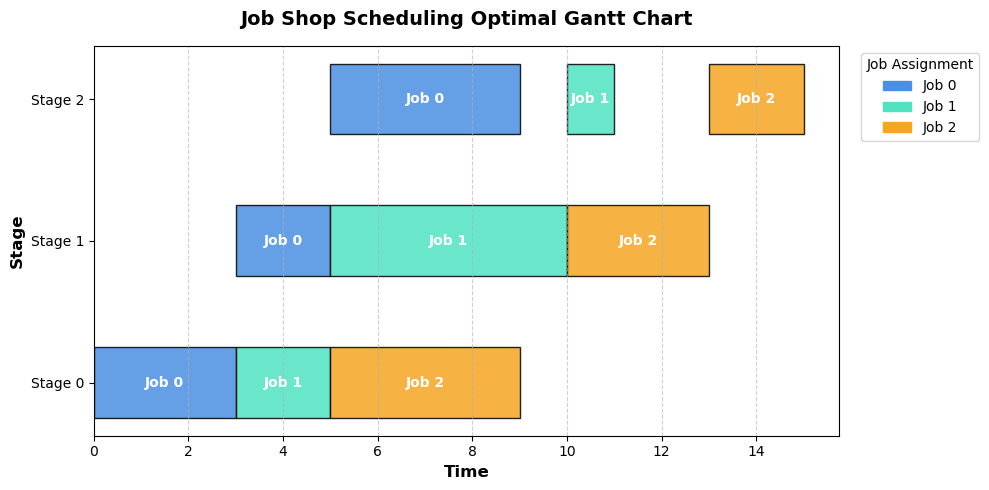

In [28]:
if model.status == COPT.OPTIMAL:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#4A90E2', '#50E3C2', '#F5A623'] 
    
    # Parse data and plot
    for j in jobs:
        for k in stages:
            end_time = C[j, k].X
            duration = Proc_time[j][k]
            start_time = end_time - duration
            
            # Draw horizontal bars for the Gantt chart
            ax.barh(y=f"Stage {k}", width=duration, left=start_time, 
                    color=colors[j], edgecolor='black', height=0.5, alpha=0.85)
            
            # Add job labels in the middle of the bars
            ax.text(start_time + duration / 2, f"Stage {k}", f"Job {j}", 
                    ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    
    # Add job labels in the middle of the bars
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Stage', fontsize=12, fontweight='bold')
    ax.set_title('Job Shop Scheduling Optimal Gantt Chart', fontsize=14, fontweight='bold', pad=15)
    
    # Add legend
    patches = [mpatches.Patch(color=colors[j], label=f'Job {j}') for j in jobs]
    ax.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc='upper left', title="Job Assignment")
    
    ax.xaxis.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Through holistic optimization, the model not only secures the shortest theoretical production delivery cycle but also reveals the dynamic balancing mechanism of capacity bottlenecks across multiple operations. Under strict constraints of machine exclusivity and operation coupling, this global scheduling solution achieves extreme minimization of idle waiting times for key equipment and precise alignment of upstream and downstream production operations. It effectively avoids resource contention and unnecessary backlogs of work-in-progress (WIP) on the shop floor, providing robust quantitative decision support for modern manufacturing enterprises in their transition toward lean and automated operations.